In [2]:
import tqdm, tifffile
import numpy as np
import os, sys
import matplotlib.pyplot as plt
import anndata as ad
import scanpy as sc

# Include src directory in the path dynamically
notebook_dir = os.path.abspath("")
src_path = os.path.join(notebook_dir, "../src")
sys.path.append(src_path)


In [15]:
PATH = "/staging/leuven/stg_00077/projects/Lorenzo/FOCUS/p_PDA/d_C1"
REFERENCE_MODALITY_NAME = 'Raman'
TARGET_MODALITY_NAME = 'MSI'
SAMPLE_ID = "PDAC011T0"

In [22]:
# Load the OME TIFF image from the reference
he_image_path = os.path.join(PATH, SAMPLE_ID, "preprocessing", REFERENCE_MODALITY_NAME, f"{SAMPLE_ID}.ome.tiff")
with tifffile.TiffFile(he_image_path) as tif:
    he_image = tif.asarray()

print(f"HE image shape: {he_image.shape}")

HE image shape: (120, 5253, 8168)


In [17]:
# Load the target modality AnnData
msi_anndata_path = os.path.join(PATH, SAMPLE_ID, "alignment", f"{SAMPLE_ID}_processed_aligned.h5ad")
msi_adata = ad.read_h5ad(msi_anndata_path)
print(f"MSI AnnData shape: {msi_adata.shape}")

MSI AnnData shape: (20383, 10254)


In [18]:
msi_adata

AnnData object with n_obs × n_vars = 20383 × 10254
    obs: 'sample_id'
    var: 'mz', 'mz_mode', 'lipid_annotation'
    uns: 'raster_size'
    obsm: 'Raman_spatial', 'raster_coordinates', 'spatial'
    layers: 'X_tic'

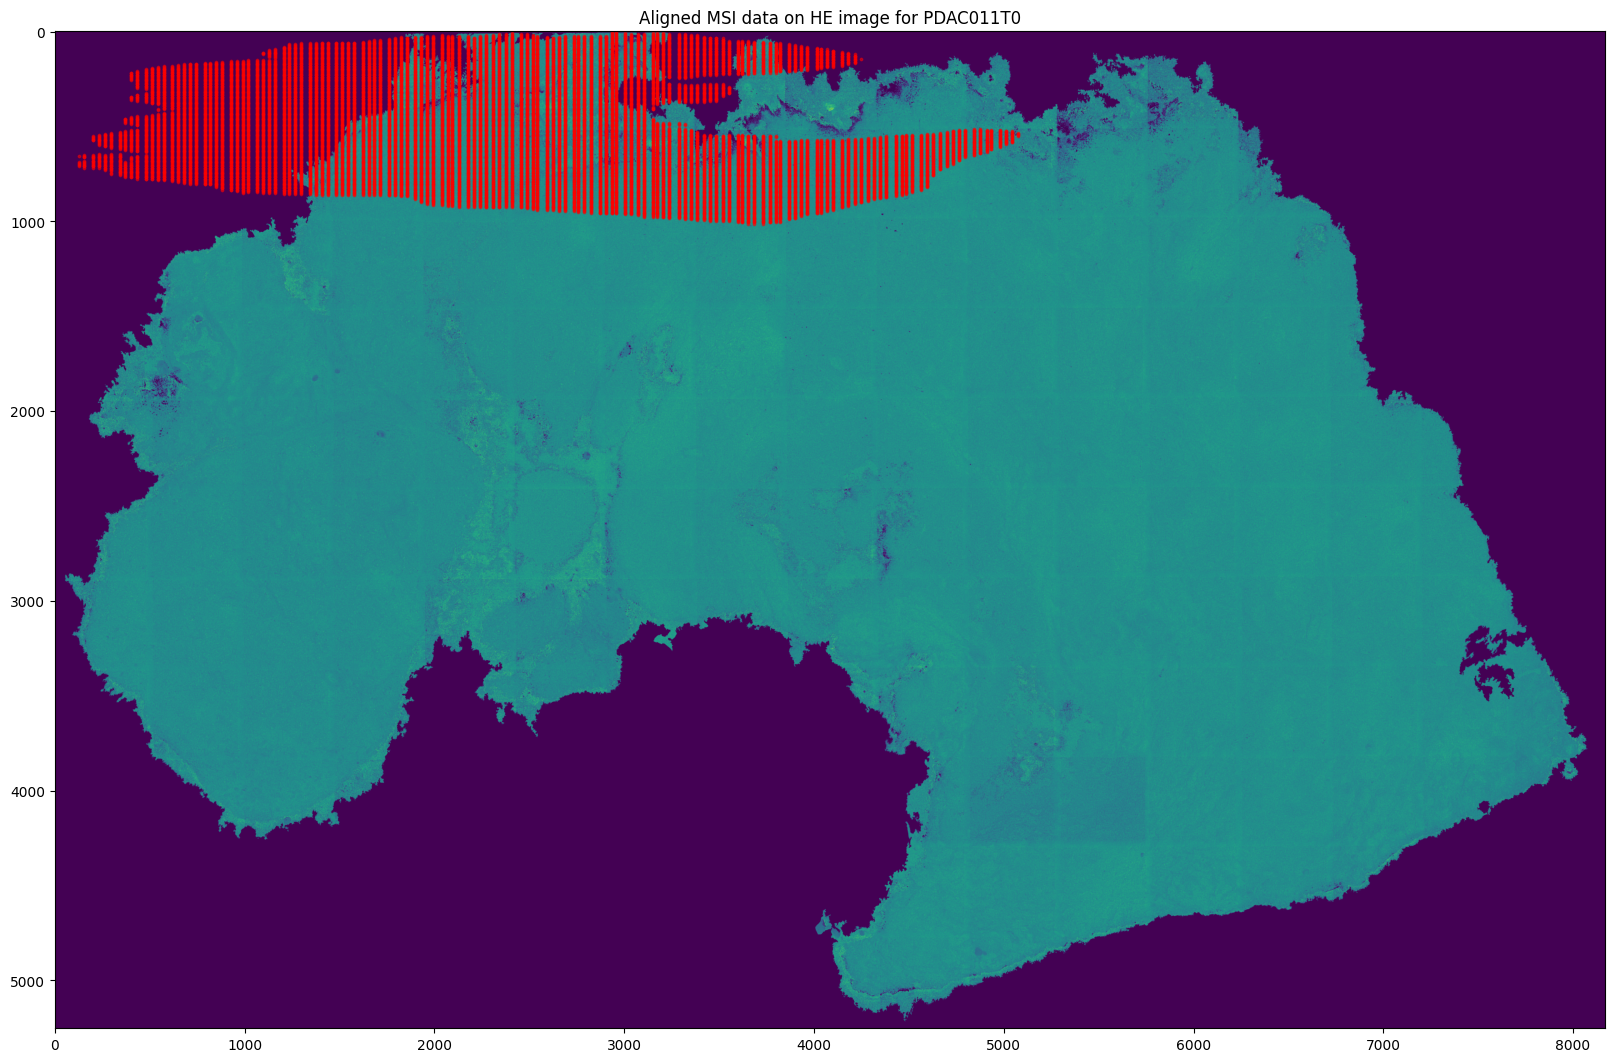

In [23]:
# Plot the image with aligned MSI data overlay
he_image = he_image.transpose(1, 2, 0)  # Convert to HWC format if needed
he_image = np.mean(he_image, axis=2)  # Convert to grayscale for better visualization
plt.figure(figsize=(20, 20))
plt.imshow(he_image)
msi_coords = msi_adata.obsm['Raman_spatial']  # Assuming spatial coordinates are stored here
plt.scatter(msi_coords[:, 1], msi_coords[:, 0], c='red', s=3, alpha=0.5)
plt.title(f"Aligned MSI data on HE image for {SAMPLE_ID}")
plt.show()